# 02 Feature Extraction
Extract and cache visual features for all dataset frames using ResNet-18. We will then apply t-SNE / UMAP for visualization to see the spread of episodes in the latent space.

In [5]:
import sys
import os
import importlib
sys.path.append(os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

import src.feature_extractor
importlib.reload(src.feature_extractor)
from src.feature_extractor import extract_and_cache_features

# Configuration for paths
save_path = os.path.abspath('../results/features_resnet18.pt')

## 1. Run Feature Extraction
This calls to our offline extractor script in `src/feature_extractor.py`. We cache the output so subsequent runs load immediately.

In [6]:
# Extract features and map
features_dict = extract_and_cache_features(save_path=save_path)

# Verify shape
first_key = list(features_dict.keys())[0]
print(f"Sample key (episode, frame): {first_key}")
print(f"Feature vector shape: {features_dict[first_key].shape}")

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Extracting features from 'observation.images.top' on cuda...


Extracting features: 100%|██████████| 20000/20000 [01:38<00:00, 202.44it/s]



Successfully saved 20000 features to /home/krisspy/Desktop/term 3-2/视觉认知工程/course-project/NeuroCore/results/features_resnet18.pt
Sample key (episode, frame): (tensor(0), tensor(0))
Feature vector shape: torch.Size([512])


## 2. Visualize the Feature Space
Because we want our distributional filtering strategy (RAS / K-means) to work smoothly, let's explore if visual frame features actually form meaningful clusters by episode or stage of the task. We'll use t-SNE for this.

Applying t-SNE to 2000 frames from episodes [0, 1, 2, 3, 4]...


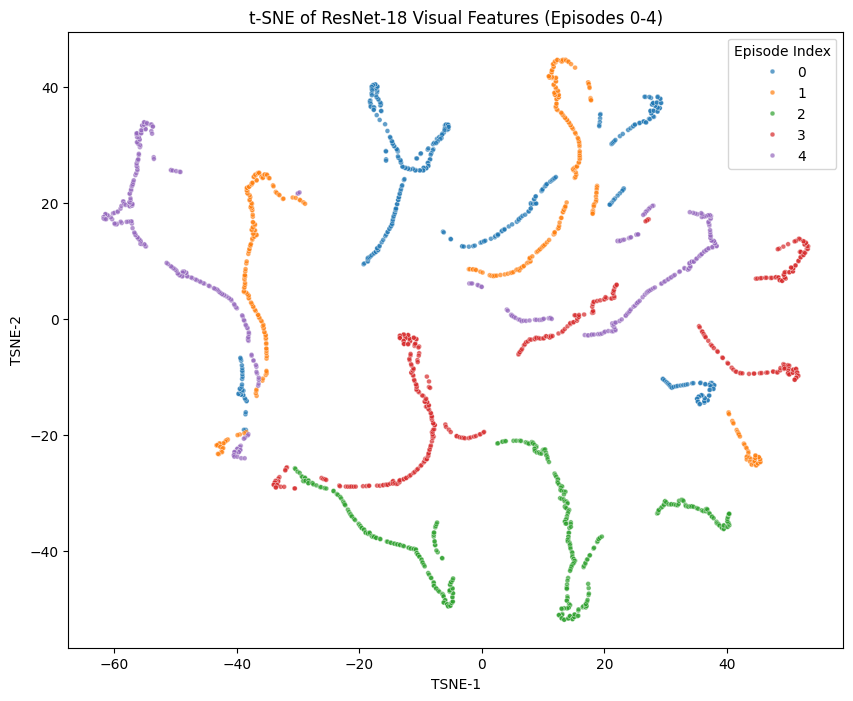

In [9]:
# Sample episodes for visualization to keep it legible (e.g. first 5 episodes)
sample_episodes = [0, 1, 2, 3, 4]
max_points_per_episode = 400
vis_features = []
vis_labels = []

# Gather vectors and labels (cap per-episode to keep plot readable)
per_episode_counts = {ep: 0 for ep in sample_episodes}
for (ep_idx, frame_idx), feat in features_dict.items():
    ep = int(ep_idx)
    if ep in sample_episodes and per_episode_counts[ep] < max_points_per_episode:
        vis_features.append(feat.numpy())
        vis_labels.append(ep)
        per_episode_counts[ep] += 1

vis_features = np.array(vis_features)

print(f"Applying t-SNE to {len(vis_features)} frames from episodes {sample_episodes}...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(vis_features)

# Plot
plt.figure(figsize=(10, 8))
palette = sns.color_palette("tab10", len(sample_episodes))
sns.scatterplot(
    x=tsne_results[:, 0],
    y=tsne_results[:, 1],
    hue=vis_labels,
    palette=palette,
    alpha=0.7,
    s=12
)
plt.title("t-SNE of ResNet-18 Visual Features (Episodes 0-4)")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.legend(title="Episode Index", loc="best")
plt.show()